In [15]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from torch.nn import BCELoss
from torch.utils.data import TensorDataset, DataLoader


In [16]:
X_train = np.random.uniform(size=(1000,2))
yxor_train = np.logical_xor(np.round(X_train[:, 0]), np.round(X_train[:, 1])).astype(int).reshape(-1, 1)

values = np.linspace(0.0, 1.0, 11)
xx, yy = np.meshgrid(values, values)
grid = np.stack([xx, yy], axis=-1)
X_test = grid.reshape(-1, 2)
yxor_test = np.logical_xor(np.round(X_test[:, 0]), np.round(X_test[:, 1])).astype(int).reshape(-1, 1)

X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
yxor_train = torch.from_numpy(yxor_train).float()

trainXOR_dataset = TensorDataset(X_train, yxor_train)
trainXOR_loader = DataLoader(trainXOR_dataset, batch_size=16)

In [17]:
loss_fn = BCELoss()

In [18]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear1 = nn.Linear(2, 4)
        self.linear2 = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.sigmoid(self.linear2(x))
        return x


In [19]:
def train_one_epoch(model, epoch_index, optimizer, data_loader):
    running_loss = 0.
    last_loss = 0.

    for i, (inputs, labels) in enumerate(data_loader):
        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        if i % 10 == 0:
            last_loss = running_loss / 1000 # loss per batch
            print(f"  epoch {epoch_index} batch {i+1} loss: {last_loss}")
            running_loss = 0.

    return last_loss

In [20]:
def train_new_model(data_loader, epochs):
    model = MLP()

    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

    model.train(True)

    for epoch in range(epochs):
        avg_loss = train_one_epoch(model, epoch, optimizer, data_loader)
        print(avg_loss)

    model.eval()

    return model


In [21]:
modelXOR = train_new_model(trainXOR_loader, 500)

  epoch 0 batch 1 loss: 0.0007244337797164917
  epoch 0 batch 11 loss: 0.006927529692649841
  epoch 0 batch 21 loss: 0.007228952705860138
  epoch 0 batch 31 loss: 0.007273667454719543
  epoch 0 batch 41 loss: 0.006927411139011383
  epoch 0 batch 51 loss: 0.006899475753307342
  epoch 0 batch 61 loss: 0.0069444900751113895
0.0069444900751113895
  epoch 1 batch 1 loss: 0.0006891962289810181
  epoch 1 batch 11 loss: 0.00683533376455307
  epoch 1 batch 21 loss: 0.0067768852710723875
  epoch 1 batch 31 loss: 0.006614698588848114
  epoch 1 batch 41 loss: 0.0067270348072052
  epoch 1 batch 51 loss: 0.006339608013629913
  epoch 1 batch 61 loss: 0.006609712481498718
0.006609712481498718
  epoch 2 batch 1 loss: 0.0006443211436271668
  epoch 2 batch 11 loss: 0.006415639638900757
  epoch 2 batch 21 loss: 0.00592966902256012
  epoch 2 batch 31 loss: 0.005766724914312363
  epoch 2 batch 41 loss: 0.00637786528468132
  epoch 2 batch 51 loss: 0.0059854348003864286
  epoch 2 batch 61 loss: 0.006295585274

0.9090909090909091


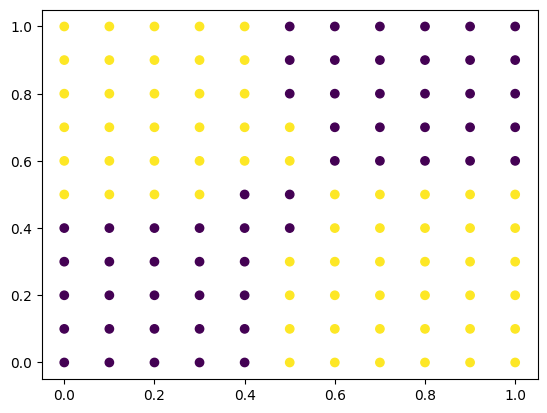

In [23]:
y_pred = modelXOR(X_test)
y_pred = np.round(y_pred.detach().numpy())
print(accuracy_score(yxor_test, y_pred))

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)